In [1]:
from firedrake import *
from firedrake.output import VTKFile
import matplotlib.pyplot as plt
import numpy as np
from firedrake.petsc import PETSc
# Get current path: all relative paths that you may use for input/output start from here.
#
# - Colab:  The default path is /content, and your GDrive folder is accessible (if mounted) at /content/drive/MyDrive
#
# - local:  If running on your local machine, current_path is the position WHERE YOU LAUNCHED THE NOTEBOOK KERNEL BY 'jupyter notebook'
#           and NOT the directory in which this ipynb file is saved.
#           If you want to modify your current path, go to the terminal, stop the kernel (ctrl-C + press y), then move to the desired path by
#           cd my/desired/path/starting/from/here
#           and then launch 'jupyter notebook'.
import os
current_path = os.getcwd()
io_path = current_path + "/cfd-labs/Lab10-NS-ChorinTemam/" 
print(io_path)

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


/home/aless/cfd-labs/Lab10-NS-ChorinTemam/



# Ex.1 NS: incremental Chorin-Temam projection method

Our goal is to solve the time-dependent Navier-Stokes method using the incremental Chorin-Temam method

\begin{equation*}
\begin{cases}
\frac{\partial  \boldsymbol{u}}{\partial t}- \Delta \boldsymbol{u} + ( \boldsymbol{u}\cdot \nabla)  \boldsymbol{u}+ \nabla  p  = \boldsymbol{0} & {\rm in} \ \Omega, t\in(0,T),\\
\nabla \cdot \boldsymbol{u} = 0 & {\rm in} \ \Omega, t\in(0,T), \\
\boldsymbol{u} = \boldsymbol{u}_\text{in} & {\rm on} \ \Gamma_{\rm{in}}, t\in(0,T),\\
\sigma(\boldsymbol{u},p)\boldsymbol{n} = h_\text{out}\boldsymbol{n} & {\rm on} \ \Gamma_{\rm{out}}, t\in(0,T), \\
\boldsymbol{u} = \boldsymbol{0} & {\rm on} \ \partial\Omega\setminus(\Gamma_\text{in}\cup\Gamma_\text{out}), t\in(0,T),\\
\boldsymbol{u}|_{t=0} = \boldsymbol{u}_\text{Stokes} & {\rm in} \ \Omega, t=0.
\end{cases}
\end{equation*}

firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (3,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (4,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (5,) is empty. This is likely an error. Did you choose the right label?


(np.float64(-3.75), np.float64(12.75), np.float64(-2.2), np.float64(2.2))

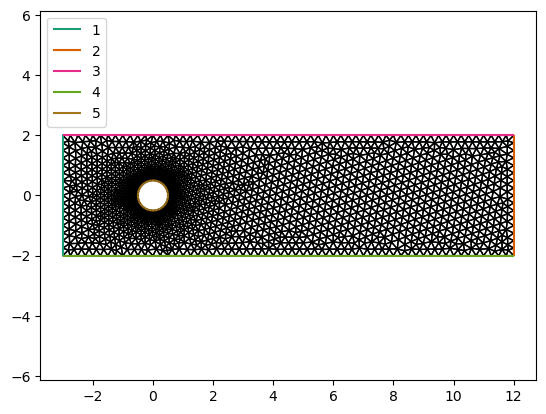

In [2]:
# Import mesh: set the path correctly!
mesh = Mesh(io_path+'mesh/cylinder-ns.msh')
fig, ax = plt.subplots()
triplot(mesh, axes=ax)
ax.legend(loc='upper left')
ax.axis('equal')

In [3]:
# Forms for incremental Chorin-Temam scheme

# Step 1
# u, v          : trial and test function for the predictor problem
# u_old, p_old  : solution from previous time step
def predictor_forms(u, v, Re, dt, u_old, p_old, neumann_data, neumann_tag):
    a = (1/dt)*inner(u, v)*dx + inner(dot(grad(u), u_old), v)*dx + (1/Re)*2*inner(sym(grad(u)), sym(grad(v)))*dx
    L = (1/dt)*inner(u_old, v)*dx - inner(grad(p_old), v)*dx + inner(neumann_data, v)*ds(neumann_tag)
    return a, L

# Step 2
# dp, q         : trial and test function for the (incremental) pressure problem
# u_tilde       : solution of predictor problem
def pressure_forms(dp, q, dt, u_tilde):
    a = inner(grad(dp), grad(q))*dx
    L = -(1/dt)*div(u_tilde)*q*dx
    return a, L

# Step 3
# ATTENTION: uh and grad(ph) belong to different FE spaces
# u, v          : trial and test function for the predictor problem
# u_tilde       : solution of predictor problem
# dp            : solution of (incremental) pressure problem
def projection_forms(u, v, u_tilde, dp, dt):
    # u = u_tilde - dt*grad(dp)
    a = inner(u, v)*dx
    L = inner(u_tilde, v)*dx - dt*inner(grad(dp), v)*dx
    return a, L

In [12]:
# Function spaces
# ATTENTION: they must be separate, no MixedFunctionSpace is needed here
V1_el = FiniteElement('CG', mesh.ufl_cell(), 1)
B_el = FiniteElement('Bubble', mesh.ufl_cell(), mesh.topological_dimension + 1)
V_el = VectorElement(NodalEnrichedElement(V1_el, B_el))
V = FunctionSpace(mesh, V_el)
Q = FunctionSpace(mesh, 'P', 1)

# Viscosity and source term
Re = 200
f = Constant((0., 0.))

# Time discretization
t0 = 0
T = 50
dt = 0.5

# Boundary conditions
FREE_SLIP_WALLS = False
x = SpatialCoordinate(mesh)
# Velocity 
inflow = (3/8*(2-x[1])*(2+x[1]), 0.)
bc_inflow = DirichletBC(V, inflow, 1)
h_out = 0.5
normal = FacetNormal(mesh)
neumann_data = h_out * normal
neumann_tag = 2
bc_noslip = DirichletBC(V, Constant((0., 0.)), (3, 4, 5))
bc_freeslip_wall = DirichletBC(V.sub(1), Constant(0.), (3, 4))
bc_noslip_cylinder = DirichletBC(V, Constant((0., 0.)), 5)
if FREE_SLIP_WALLS:
    bcsU = [bc_inflow, bc_freeslip_wall, bc_noslip_cylinder]
else:
    bcsU = [bc_inflow, bc_noslip]
# Pressure
bscP = [DirichletBC(Q, Constant(0.), 2)]

In [13]:
# Initial condition: Stokes problem

# We define the mixed function space (ONLY) for the Stokes problem, and the trial and test functions
W = MixedFunctionSpace([V, Q])
uu, pp = TrialFunctions(W)
vv, qq = TestFunctions(W)

# Forms for Stokes problem
a_init = (2/Re)*inner(sym(grad(uu)), sym(grad(vv)))*dx - pp * div(vv) * dx + div(uu) * qq *dx
L_init = inner(f, vv)*dx + inner(neumann_data, vv)*ds(neumann_tag)

# Boundary conditions
if FREE_SLIP_WALLS:
    bcs = [DirichletBC(W.sub(0).sub(0), inflow[0], 1), DirichletBC(W.sub(0).sub(1), Constant(0.), (3, 4)), DirichletBC(W.sub(0), Constant((0., 0.)), 5)]
else:
    bcs = [DirichletBC(W.sub(0), inflow, 1), DirichletBC(W.sub(0), Constant((0., 0.)), (3, 4, 5))]

wh_init = Function(W)
init_problem = LinearVariationalProblem(a_init, L_init, wh_init, bcs=bcs)
param_init = {'ksp_type': 'preonly', 'pc_type': 'lu'}
solver_init =  LinearVariationalSolver(init_problem, solver_parameters=param_init)
solver_init.solve()
uh_init, ph_init = wh_init.subfunctions

# Functions on separated space, for C-T scheme
uh_old = Function(V)
ph_old = Function(Q)
uh_old.assign(uh_init)
ph_old.assign(ph_init)

Coefficient(WithGeometry(FunctionSpace(<firedrake.mesh.MeshTopology object at 0x75375e1998e0>, FiniteElement('Lagrange', triangle, 1), name=None), Mesh(VectorElement(FiniteElement('Lagrange', triangle, 1), dim=2), 1)), 1692)

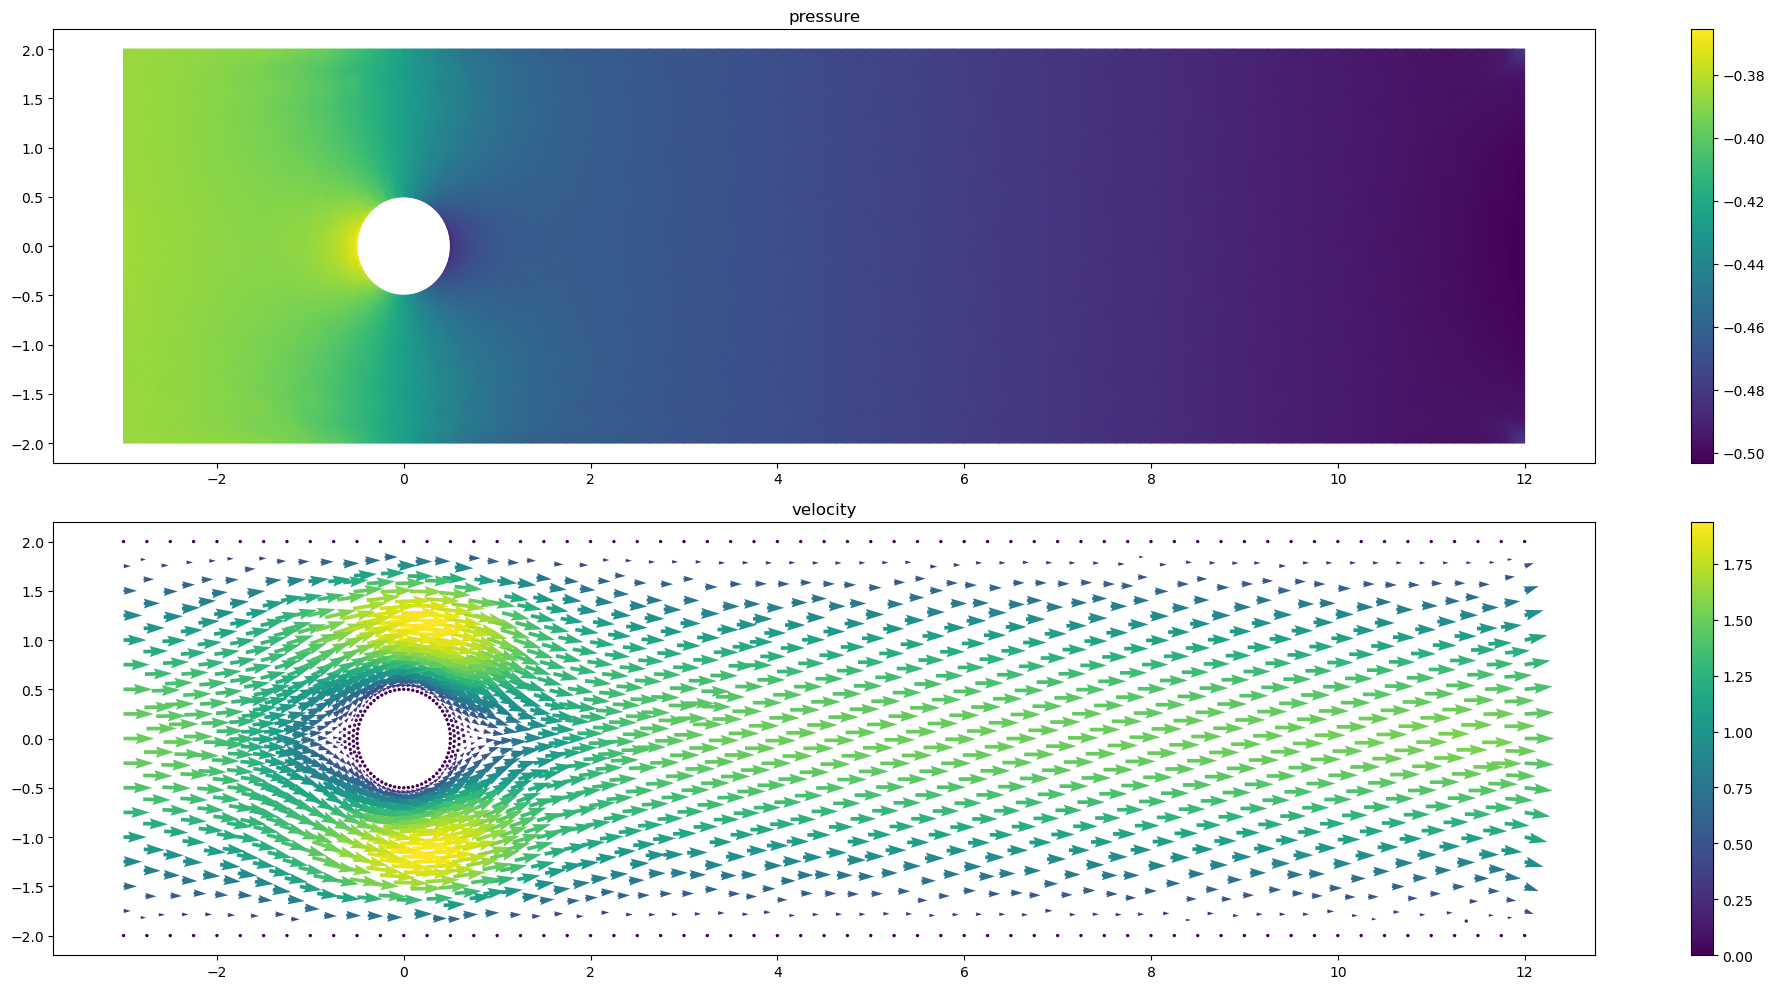

In [14]:
fig, ax = plt.subplots(2, 1, figsize=(20, 10))

col0 = tripcolor(ph_old, axes=ax[0])
fig.colorbar(col0, ax=ax[0])
ax[0].set_title('pressure')

col1 = quiver(uh_old, axes=ax[1])
fig.colorbar(col1, ax=ax[1])
ax[1].set_title('velocity')

plt.tight_layout()

# vtk output for Paraview
outdir = io_path+"output/"
if FREE_SLIP_WALLS:
    outfile = VTKFile(outdir+"solution_freeslip.pvd")
else:
    outfile = VTKFile(outdir+"solution_noslip.pvd")
uh_old.rename("Velocity")   # this names will be used in Paraview
ph_old.rename("Pressure")
outfile.write(uh_old, ph_old, time=t0)

In [15]:
# Define the solvers for each time step, using the forms defined above. 
# We will use them in the time loop.

# Functions for the variational problems
u = TrialFunction(V)    # u_tilde
v = TestFunction(V)     # test function for the predictor problem
dp = TrialFunction(Q)   # increment of pressure
q = TestFunction(Q)     # test function for the pressure problem

# Actual solutions
uh = Function(V)        # solution of predictor problem
dph = Function(Q)       # increment of pressure

# Step 1
predictor_a, predictor_L = predictor_forms(u, v, Re, dt, uh_old, ph_old, neumann_data, neumann_tag)
predictor_problem = LinearVariationalProblem(predictor_a, predictor_L, uh, bcs=bcsU)
param_predictor = {'ksp_type': 'preonly', 'pc_type': 'lu'}
solver_predictor = LinearVariationalSolver(predictor_problem, solver_parameters=param_predictor)

# Step 2
pressure_a, pressure_L = pressure_forms(dp, q, dt, uh)
pressure_problem = LinearVariationalProblem(pressure_a, pressure_L, dph, bcs=bscP)
param_pressure = {'ksp_type': 'preonly', 'pc_type': 'lu'}
solver_pressure = LinearVariationalSolver(pressure_problem, solver_parameters=param_pressure)

# Step 3
projection_a, projection_L = projection_forms(u, v, uh, dph, dt)
projection_problem = LinearVariationalProblem(projection_a, projection_L, uh, bcs=bcsU)
param_projection = {'ksp_type': 'preonly', 'pc_type': 'lu'}
solver_projection = LinearVariationalSolver(projection_problem, solver_parameters=param_projection)

In [16]:
# Time loop

step = 0
nsteps = int((T-t0)/dt) + 1
drag_vec = [0.0] * nsteps
lift_vec = [0.0] * nsteps
drag_vec[0] = assemble(inner(ph_old*normal - 2.0/Re*dot(sym(grad(uh_old)), normal), Constant((1.,0.))) * ds(5))
lift_vec[0] = assemble(inner(ph_old*normal - 2.0/Re*dot(sym(grad(uh_old)), normal), Constant((0.,1.))) * ds(5))
for t in dt + np.arange(t0, T, dt):  
    step += 1
    # Print the current time and the norms of the previous solution to check that the solution is not blowing up
    print(f'Step: {step}, t = {t:.2f}, ||u||H1 = {norm(uh_old,"H1"):.6f}, ||p||L2 = {norm(ph_old,"L2"):.6f}')

    # Step 1
    solver_predictor.solve()

    # Step 2
    solver_pressure.solve()

    # Step 3
    solver_projection.solve()

    # Update the solution for the next time step
    uh_old.assign(uh)
    ph_old.dat += dph.dat

    # # Equivalently
    # tmp_p = ph_old + dph
    # ph_old.assign(tmp_p)

    drag_vec[step] = assemble(inner( ph_old*normal - 2.0/Re*dot(sym(grad(uh_old)), normal), Constant((1.,0.))) * ds(5))
    lift_vec[step] = assemble(inner( ph_old*normal - 2.0/Re*dot(sym(grad(uh_old)), normal), Constant((0.,1.))) * ds(5))

    # Post-processing
    outfile.write(uh_old, ph_old, time=t)

Step: 1, t = 0.50, ||u||H1 = 12.852304, ||p||L2 = 3.559883
Step: 2, t = 1.00, ||u||H1 = 19.066092, ||p||L2 = 3.505063
Step: 3, t = 1.50, ||u||H1 = 18.131739, ||p||L2 = 3.434793
Step: 4, t = 2.00, ||u||H1 = 18.572519, ||p||L2 = 3.538091
Step: 5, t = 2.50, ||u||H1 = 18.648378, ||p||L2 = 3.640480
Step: 6, t = 3.00, ||u||H1 = 18.787644, ||p||L2 = 3.747492
Step: 7, t = 3.50, ||u||H1 = 18.906407, ||p||L2 = 3.849221
Step: 8, t = 4.00, ||u||H1 = 19.019412, ||p||L2 = 3.955554
Step: 9, t = 4.50, ||u||H1 = 19.091542, ||p||L2 = 4.063965
Step: 10, t = 5.00, ||u||H1 = 19.155930, ||p||L2 = 4.170437
Step: 11, t = 5.50, ||u||H1 = 19.219858, ||p||L2 = 4.270457
Step: 12, t = 6.00, ||u||H1 = 19.285736, ||p||L2 = 4.363589
Step: 13, t = 6.50, ||u||H1 = 19.350965, ||p||L2 = 4.450528
Step: 14, t = 7.00, ||u||H1 = 19.417100, ||p||L2 = 4.532442
Step: 15, t = 7.50, ||u||H1 = 19.485525, ||p||L2 = 4.610081
Step: 16, t = 8.00, ||u||H1 = 19.556714, ||p||L2 = 4.683715
Step: 17, t = 8.50, ||u||H1 = 19.629407, ||p||L2 

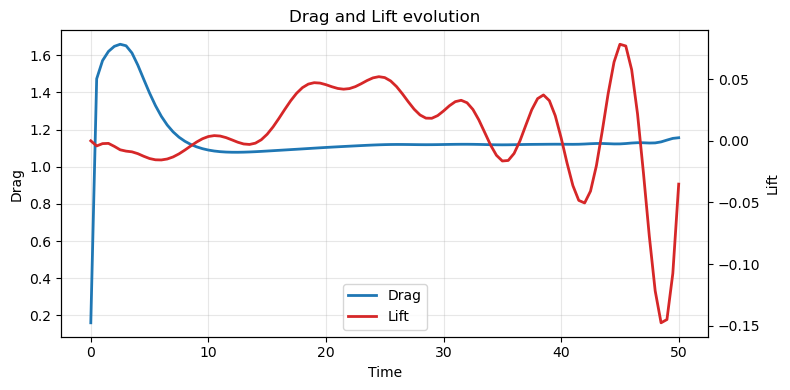

In [17]:
fig, ax1 = plt.subplots(figsize=(8, 4))

t_vec = [t0] + (dt + np.arange(t0, T, dt)).tolist()

# Drag axis
line1 = ax1.plot(
    t_vec, drag_vec,
    label='Drag',
    linewidth=2
)
ax1.set_xlabel('Time')
ax1.set_ylabel('Drag')
ax1.grid(True, alpha=0.3)

# Lift axis
ax2 = ax1.twinx()

line2 = ax2.plot(
    t_vec, lift_vec,
    label='Lift',
    color='tab:red',
    linewidth=2
)

ax2.set_ylabel('Lift')
ax2.tick_params(axis='y')

# Combined legend
lines = line1 + line2
labels = [l.get_label() for l in lines]

ax1.legend(
    lines,
    labels,
    loc='lower center',
    frameon=True
)

plt.title('Drag and Lift evolution')
plt.tight_layout()
plt.show()